In [14]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [15]:
import math
import random

from util.vec3 import Vec3
from util.material import Material
from util.metal.lambertian import Lambertian 
from util.metal.dielectric import Dielectric
from util.metal.metal_fuzz import Metal
from util.metal.hittable_list import HittableList
from util.metal.sphere import Sphere
from util.week1.camera import Camera



# ============================================================
# RANDOM HELPERS (C++ → Python equivalent)
# ============================================================
def random_double(min_val=0.0, max_val=1.0):
    return min_val + (max_val - min_val) * random.random()


def random_color(min_val=0.0, max_val=1.0):
    return Vec3(
        random_double(min_val, max_val),
        random_double(min_val, max_val),
        random_double(min_val, max_val),
    )


# ============================================================
# BUILD WORLD (NO main wrapper)
# ============================================================

world = HittableList()

# --------------------------
# Ground (big sphere)
# --------------------------
ground_material = Lambertian(Vec3(0.5, 0.5, 0.5))

world.add(
    Sphere(
        center=Vec3(0, -1000, 0),
        radius=1000,
        material=ground_material
    )
)

# --------------------------
# Random small spheres
# --------------------------
for a in range(-11, 11):
    for b in range(-11, 11):

        choose_mat = random_double()

        center = Vec3(
            a + 0.9 * random_double(),
            0.2,
            b + 0.9 * random_double()
        )

        # avoid overlap with main center sphere
        if (center - Vec3(4, 0.2, 0)).length() > 0.9:

            # diffuse
            if choose_mat < 0.8:

                albedo = random_color() * random_color()
                mat = Lambertian(albedo)

                world.add(Sphere(center, 0.2, mat))

            # metal
            elif choose_mat < 0.95:

                albedo = random_color(0.5, 1.0)
                fuzz = random_double(0.0, 0.5)

                mat = Metal(albedo, fuzz)

                world.add(Sphere(center, 0.2, mat))

            # glass
            else:

                mat = Dielectric(1.5)

                world.add(Sphere(center, 0.2, mat))


# --------------------------
# Big center objects
# --------------------------
world.add(Sphere(Vec3(0, 1, 0), 1.0, Dielectric(1.5)))
world.add(Sphere(Vec3(-4, 1, 0), 1.0, Lambertian(Vec3(0.4, 0.2, 0.1))))
world.add(Sphere(Vec3(4, 1, 0), 1.0, Metal(Vec3(0.7, 0.6, 0.5), 0.0)))


# ============================================================
# CAMERA SETUP
# ============================================================

cam = Camera()

cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 100
cam.samples_per_pixel = 10
cam.max_depth = 50

cam.vfov = 20

# camera position (important change)
cam.lookfrom = Vec3(13, 2, 3)
cam.lookat   = Vec3(0, 0, 0)
cam.vup      = Vec3(0, 1, 0)

# defocus blur
cam.defocus_angle = 0.6
cam.focus_dist = 10.0


# =========================
# READY TO RENDER
# =========================
cam.render(world)

100%|██████████| 56/56 [02:56<00:00,  3.15s/it, CPU=41.7%, RAM=85.0%, CPU Temp=N/A, GPU Temp=54.0°C, VRAM=914.0MB]

Render complete → output.ppm


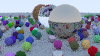

In [17]:
cam.show()